In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [3]:
# loading data
df = pd.read_csv("../data/student-mat.csv", sep=";")

In [4]:
df.shape

(395, 33)

In [5]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [8]:
# basic info
print("Columns: ", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nNull values:\n", df.isnull().sum())
print("\nBasic stats:")
df.describe()

Columns:  ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Data types:
 school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [9]:
# creating pass/fail column based on final grade
# G3 >= 10 is passing in Portuguese grading system
df["pass_fail"] = df["G3"].apply(lambda x: "Pass" if x >= 10 else "Fail")

# verify
print(df["pass_fail"].value_counts())
print("\nPass rate:", round(df["pass_fail"].value_counts(normalize=True)["Pass"] * 100, 1), "%")

pass_fail
Pass    265
Fail    130
Name: count, dtype: int64

Pass rate: 67.1 %


In [10]:
# checking distribution of key numeric columns
cols = ["age", "studytime", "failures", "absences", "G1", "G2", "G3"]

for col in cols:
    print(f"{col}:")
    print(f"  mean: {df[col].mean():.2f}  |  median: {df[col].median()}  |  std: {df[col].std():.2f}  |  min: {df[col].min()}  |  max: {df[col].max()}")
    print()

age:
  mean: 16.70  |  median: 17.0  |  std: 1.28  |  min: 15  |  max: 22

studytime:
  mean: 2.04  |  median: 2.0  |  std: 0.84  |  min: 1  |  max: 4

failures:
  mean: 0.33  |  median: 0.0  |  std: 0.74  |  min: 0  |  max: 3

absences:
  mean: 5.71  |  median: 4.0  |  std: 8.00  |  min: 0  |  max: 75

G1:
  mean: 10.91  |  median: 11.0  |  std: 3.32  |  min: 3  |  max: 19

G2:
  mean: 10.71  |  median: 11.0  |  std: 3.76  |  min: 0  |  max: 19

G3:
  mean: 10.42  |  median: 11.0  |  std: 4.58  |  min: 0  |  max: 20



In [11]:
# distribution of categorical columns
cat_cols = ["sex", "address", "Pstatus", "schoolsup", "famsup", 
            "paid", "activities", "internet", "romantic", "higher"]

for col in cat_cols:
    print(f"{col}:\n{df[col].value_counts().to_string()}\n")

sex:
sex
F    208
M    187

address:
address
U    307
R     88

Pstatus:
Pstatus
T    354
A     41

schoolsup:
schoolsup
no     344
yes     51

famsup:
famsup
yes    242
no     153

paid:
paid
no     214
yes    181

activities:
activities
yes    201
no     194

internet:
internet
yes    329
no      66

romantic:
romantic
no     263
yes    132

higher:
higher
yes    375
no      20



In [12]:
# how key numeric variables relate to final grade
bivariate_cols = ["studytime", "failures", "absences", "G1", "G2", "Medu", "Fedu"]

for col in bivariate_cols:
    grouped = df.groupby(col)["G3"].mean().round(2)
    print(f"Average G3 by {col}:")
    print(grouped.to_string())
    print()

Average G3 by studytime:
studytime
1    10.05
2    10.17
3    11.40
4    11.26

Average G3 by failures:
failures
0    11.25
1     8.12
2     6.24
3     5.69

Average G3 by absences:
absences
0      8.44
1     13.00
2     11.91
3     11.50
4     11.28
5     11.60
6     11.77
7     11.86
8     10.59
9     13.33
10    11.24
11    11.67
12    10.75
13    12.67
14     9.33
15     8.33
16     9.86
17    10.00
18     8.40
19    10.00
20    11.50
21    18.00
22     8.00
23    13.00
24    18.00
25    11.00
26     6.00
28     9.00
30     8.00
38     8.00
40    11.00
54    11.00
56     8.00
75     9.00

Average G3 by G1:
G1
3      5.00
4      0.00
5      4.43
6      4.21
7      5.59
8      8.12
9      8.06
10     9.25
11    10.74
12    11.97
13    12.76
14    13.80
15    14.67
16    16.05
17    16.88
18    18.12
19    19.00

Average G3 by G2:
G2
0      0.00
4      0.00
5      3.27
6      4.79
7      5.90
8      7.44
9      8.22
10     9.78
11    10.94
12    11.93
13    13.11
14    14.13
15    15.

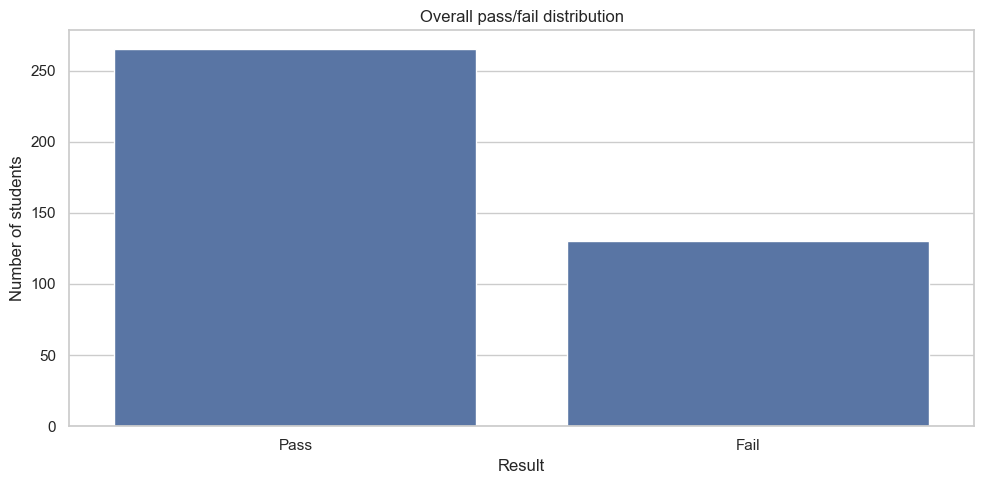

In [20]:
# chart 1: overall pass/fail distribution
# countplot counts how many students are in each category automatically

sns.countplot(data=df, x="pass_fail", order=["Pass", "Fail"])

plt.title("Overall pass/fail distribution")
plt.xlabel("Result")
plt.ylabel("Number of students")

plt.tight_layout()
plt.savefig("../screenshots/chart1_pass_fail.png", dpi=150)
plt.show()

# insight
# 265 passed (67.1%) and 130 failed (32.9%)
# nearly 1 in 3 students is failing -- matches SQL finding exactly

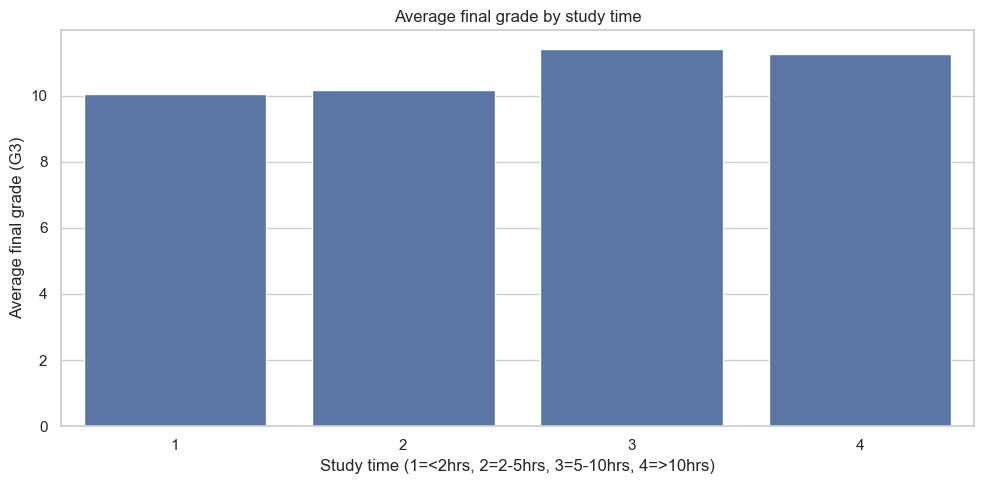

In [21]:
# chart 2: average final grade by study time
# barplot shows the mean G3 for each study time group automatically

sns.barplot(data=df, x="studytime", y="G3", errorbar=None)

plt.title("Average final grade by study time")
plt.xlabel("Study time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs)")
plt.ylabel("Average final grade (G3)")

plt.tight_layout()
plt.savefig("../screenshots/chart2_studytime_grade.png", dpi=150)
plt.show()

# insight
# grades improve as study time increases from 1 to 3
# studytime 4 dips slightly below 3 -- possibly burnout or weaker students studying more
# majority of students (198) are in studytime 2 -- room for improvement

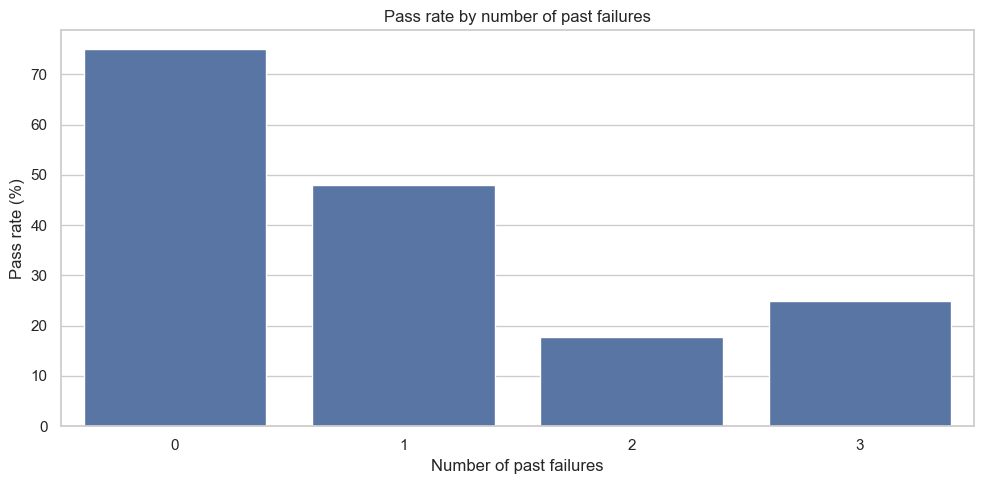

In [22]:
# chart 3: pass rate by number of past failures
# calculating pass rate for each failures group manually first
failure_groups = df.groupby("failures")["pass_fail"].value_counts(normalize=True).unstack()

# normalize=True gives proportions, multiply by 100 for percentage
failure_groups = failure_groups * 100

# plotting just the Pass percentage per failures group
sns.barplot(x=failure_groups.index, y=failure_groups["Pass"], errorbar=None)

plt.title("Pass rate by number of past failures")
plt.xlabel("Number of past failures")
plt.ylabel("Pass rate (%)")

plt.tight_layout()
plt.savefig("../screenshots/chart3_failures_passrate.png", dpi=150)
plt.show()

# insight
# 0 past failures: 75% pass rate
# 1 past failure: drops to 48% -- almost halved
# 2+ failures: below 25% chance of passing
# past failures is the strongest risk indicator in the dataset

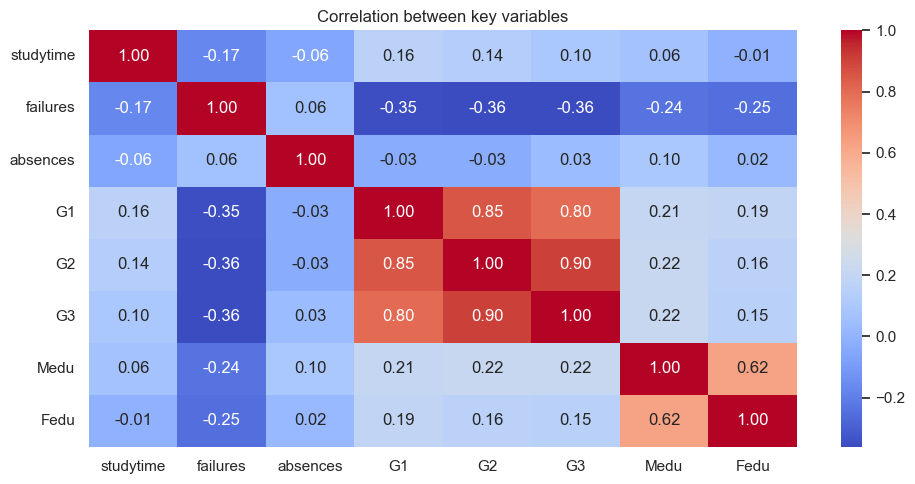

In [23]:
# chart 4: correlation heatmap
# selecting only numeric columns that are meaningful for analysis
numeric_cols = ["studytime", "failures", "absences", "G1", "G2", "G3", "Medu", "Fedu"]

# corr() calculates correlation between every pair of columns
# values range from -1 (opposite) to +1 (same direction)
correlation = df[numeric_cols].corr()

sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation between key variables")

plt.tight_layout()
plt.savefig("../screenshots/chart4_correlation_heatmap.png", dpi=150)
plt.show()

# insight
# G1 and G2 are very strongly correlated with G3 (as expected)
# failures has a clear negative correlation with G3
# absences has a weak negative correlation -- not as strong as expected
# Medu and Fedu are mildly positively correlated with G3

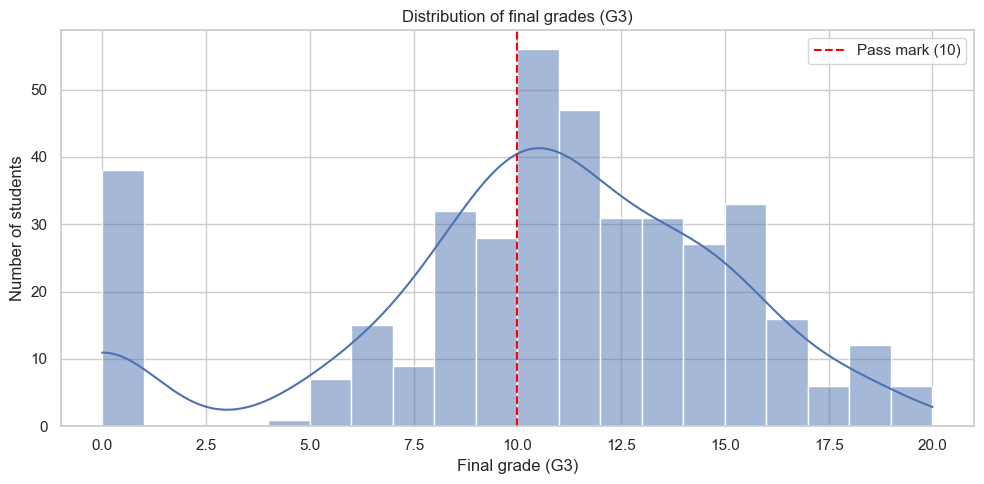

In [24]:
# chart 5: distribution of final grades
# histplot shows how many students got each grade
# kde=True adds a smooth curve on top to show the overall shape

sns.histplot(data=df, x="G3", bins=20, kde=True)

plt.title("Distribution of final grades (G3)")
plt.xlabel("Final grade (G3)")
plt.ylabel("Number of students")

# marking the pass line at grade 10
plt.axvline(x=10, color="red", linestyle="--", label="Pass mark (10)")
plt.legend()

plt.tight_layout()
plt.savefig("../screenshots/chart5_grade_distribution.png", dpi=150)
plt.show()

# insight
# large spike at 0 -- 38 students completely disengaged
# distribution is roughly normal between grades 8-16
# red line at 10 clearly shows how many students fall below the pass mark
# the spike at 0 is abnormal and skews the average down

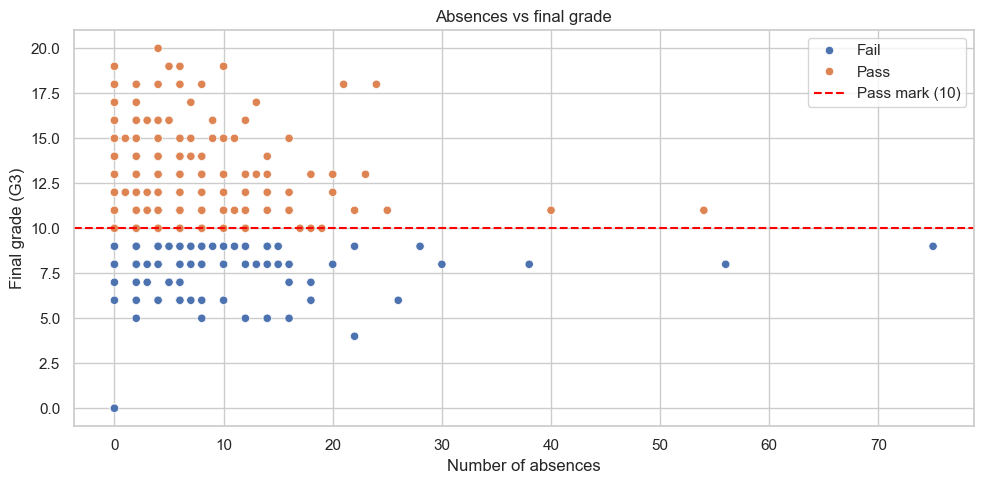

In [26]:
# chart 6: absences vs final grade
# scatterplot shows each student as a dot
# hue splits dots by pass/fail so we can see the pattern clearly

sns.scatterplot(data=df, x="absences", y="G3", hue="pass_fail")

plt.title("Absences vs final grade")
plt.xlabel("Number of absences")
plt.ylabel("Final grade (G3)")

# marking the pass line
plt.axhline(y=10, color="red", linestyle="--", label="Pass mark (10)")
plt.legend()

plt.tight_layout()
plt.savefig("../screenshots/chart6_absences_vs_grade.png", dpi=150)
plt.show()

# insight
# students with very high absences (30+) are almost all below the pass line
# but many students with low absences also fail -- absences alone doesnt explain failure
# the student with 75 absences is clearly visible as an extreme outlier
# confirms absences is a contributing factor but not the sole cause of failure

In [27]:
# ── EDA SUMMARY ──────────────────────────────────────────────

print("=" * 55)
print("STUDENT PERFORMANCE EDA -- KEY FINDINGS")
print("=" * 55)

print(f"\n1. dataset: {df.shape[0]} students, {df.shape[1]} columns, 0 nulls")

pass_rate = round(df["pass_fail"].value_counts(normalize=True)["Pass"] * 100, 1)
fail_rate = round(100 - pass_rate, 1)
print(f"\n2. overall: {pass_rate}% passed, {fail_rate}% failed")

zero_scorers = len(df[df["G3"] == 0])
print(f"\n3. {zero_scorers} students scored 0 on final exam (complete disengagement)")

avg_absences_fail = round(df[df["pass_fail"] == "Fail"]["absences"].mean(), 2)
avg_absences_pass = round(df[df["pass_fail"] == "Pass"]["absences"].mean(), 2)
print(f"\n4. avg absences -- pass: {avg_absences_pass}, fail: {avg_absences_fail}")

print(f"\n5. past failures is the strongest risk factor")
print(f"   0 failures: 75% pass rate")
print(f"   1 failure:  48% pass rate")
print(f"   2+ failures: below 25% pass rate")

print(f"\n6. G2 is the strongest predictor of G3")
print(f"   early intervention after period 2 results is most effective")

print("\n" + "=" * 55)
print("charts saved to screenshots/ folder")
print("=" * 55)

STUDENT PERFORMANCE EDA -- KEY FINDINGS

1. dataset: 395 students, 34 columns, 0 nulls

2. overall: 67.1% passed, 32.9% failed

3. 38 students scored 0 on final exam (complete disengagement)

4. avg absences -- pass: 5.19, fail: 6.76

5. past failures is the strongest risk factor
   0 failures: 75% pass rate
   1 failure:  48% pass rate
   2+ failures: below 25% pass rate

6. G2 is the strongest predictor of G3
   early intervention after period 2 results is most effective

charts saved to screenshots/ folder
